<a href="https://colab.research.google.com/github/mikysetiawan/MachineLearningExpert/blob/master/Tugas_Akhir_Timeseries_Forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [2]:
csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'

df = pd.read_csv(csv_url, parse_dates=['Date'], index_col='Date')

df.head()

,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
Date,,,,,,
2017-09-21 09:00:00.000,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
2017-09-21 10:00:00.000,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2017-09-21 11:00:00.000,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
2017-09-21 12:00:00.000,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
2017-09-21 13:00:00.000,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53150 entries, 2017-09-21 09:00:00.000 to 2023-10-19 23:00:00
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Close        53150 non-null  float64
 1   Volume USDT  53150 non-null  float64
 2   RSI          53150 non-null  float64
 3   MACD_Hist    53150 non-null  float64
 4   ATR          53150 non-null  float64
 5   KAMAO        53150 non-null  float64
dtypes: float64(6)
memory usage: 2.8+ MB


In [4]:
def adf_test(series):
    result = adfuller(series, autolag='AIC')

    print("ADF Test Results:")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] <= 0.05:
        print("Data stasioner")
    else:
        print("Data tidak stasioner")

adf_test(df['Close'])

ADF Test Results:
ADF Statistic: -1.559401139461609
p-value: 0.5039489237257476
Data tidak stasioner


In [ ]:
print("===== adf test Volume USDT ==========")
adf_test(df['Volume USDT'])
print("===== adf test RSI ==========")
adf_test(df['RSI'])
print("===== adf test MACD_Hist ==========")
adf_test(df['MACD_Hist'])
print("===== adf test ATR ==========")
adf_test(df['ATR'])
print("===== adf test KAMAO ==========")
adf_test(df['KAMAO'])

===== adf test Volume USDT ==========
ADF Test Results:
ADF Statistic: -8.370741375695141
p-value: 2.6665450890014613e-13
Data stasioner
===== adf test RSI ==========
ADF Test Results:
ADF Statistic: -8.23940675812908
p-value: 5.771375320348243e-13
Data stasioner
===== adf test MACD_Hist ==========
ADF Test Results:
ADF Statistic: -13.057517328088691
p-value: 2.0799966877462827e-24
Data stasioner
===== adf test ATR ==========
ADF Test Results:
ADF Statistic: -1.8613754244450191
p-value: 0.3504436609247079
Data tidak stasioner
===== adf test KAMAO ==========
ADF Test Results:
ADF Statistic: -14.416472567986332
p-value: 8.043618591043793e-27
Data stasioner


In [7]:
# Check the number of missing values in each column
df.isnull().sum()

,0
Close,0
Volume USDT,0
RSI,0
MACD_Hist,0
ATR,0
KAMAO,0


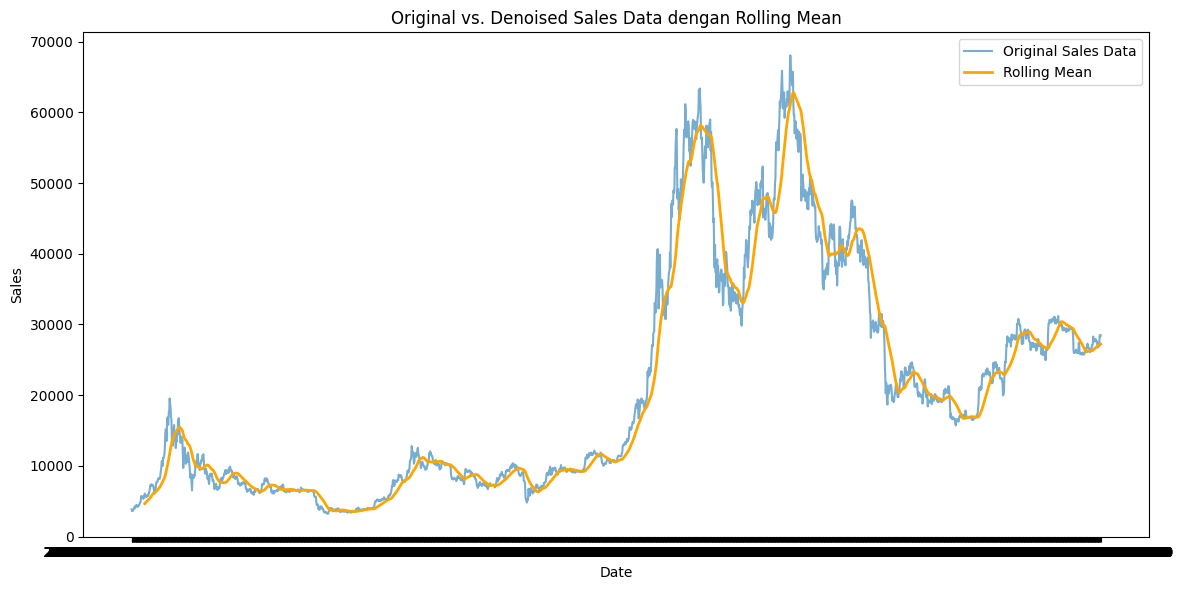

In [6]:
# 720 = monthly (the data is hourly, 24 * 30 = 720)
rolling_data = df['Close'].rolling(window=720).mean()

plt.figure(figsize=(12, 6))

# [::24] takes every 24th row (1 every day)
plt.plot(df.index[::24], df['Close'][::24], label='Original Sales Data', alpha=0.6)
plt.plot(df.index[::24], rolling_data[::24], label='Rolling Mean', color='orange', linewidth=2)

plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Original vs. Denoised Sales Data dengan Rolling Mean')
plt.legend()
plt.tight_layout()
plt.show()

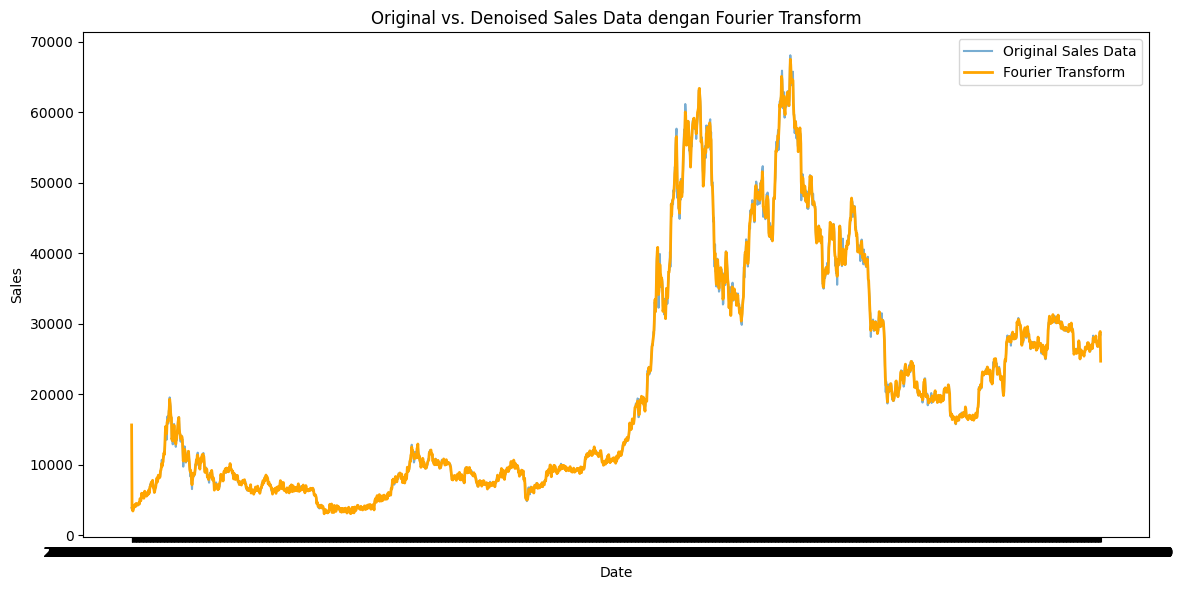

In [22]:
def fft_denoiser(series, threshold_quantile=0.98):

    # 1. Lakukan FFT
    fft_values = np.fft.fft(series)

    # 2. Filter dengan menetapkan threshold
    psd = np.abs(fft_values) ** 2
    threshold = np.quantile(psd, threshold_quantile)
    fft_filtered = fft_values.copy()
    fft_filtered[psd < threshold] = 0

    # 3. Lakukan Inverse FFT untuk mendapatkan sinyal bersih
    denoised_signal = np.fft.ifft(fft_filtered).real

    return denoised_signal

denoised_data = fft_denoiser(df['Close'])
# Masukkan hasil FFT utuh ke DataFrame
df['Close_FFT'] = denoised_data

plt.figure(figsize=(12, 6))

# [::24] takes every 24th row (1 every day)
plt.plot(df.index[::24], df['Close'][::24], label='Original Sales Data', alpha=0.6)
plt.plot(df.index[::24], denoised_data[::24], label='Fourier Transform', color='orange', linewidth=2)

plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Original vs. Denoised Sales Data dengan Fourier Transform')
plt.legend()
plt.tight_layout()
plt.show()

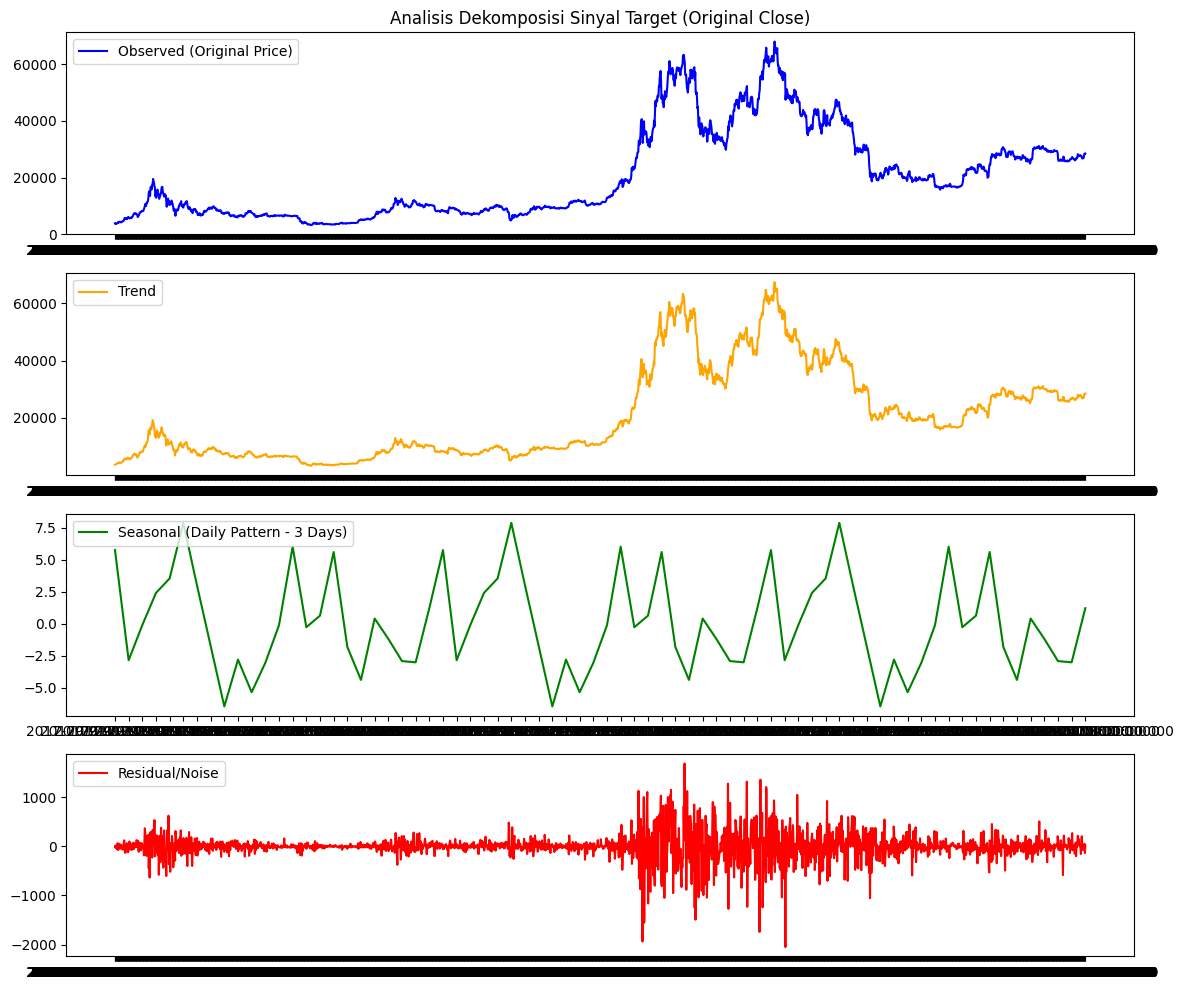

In [20]:
# Hitung dekomposisi dari data 'Close' asli
decomposition = seasonal_decompose(df['Close'], model='additive', period=24)

plt.figure(figsize=(12, 10))

plt.subplot(411)
plt.plot(df.index[::24], decomposition.observed[::24], label='Observed (Original Price)', color='blue')
plt.legend(loc='upper left')
plt.title('Analisis Dekomposisi Sinyal Target (Original Close)')

plt.subplot(412)
plt.plot(df.index[::24], decomposition.trend[::24], label='Trend', color='orange')
plt.legend(loc='upper left')

# Menampilkan grafik seasonal 3 hari pertama saja agar gelombang hariannya terlihat jelas di laporan
plt.subplot(413)
plt.plot(df.index[:72], decomposition.seasonal[:72], label='Seasonal (Daily Pattern - 3 Days)', color='green')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(df.index[::24], decomposition.resid[::24], label='Residual/Noise', color='red')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [25]:
# Buang 100 baris pertama langsung dari DataFrame untuk menghilangkan anomali awal FFT
df_clean = df.iloc[100:].copy()

# Feature Engineering: Rolling Std Dev
df_clean['Close_Volatilitas_24h'] = df_clean['Close_FFT'].rolling(window=24).std().bfill()

features = ['Close_FFT', 'Volume USDT', 'RSI', 'MACD_Hist', 'Close_Volatilitas_24h']
df_filtered = df_clean[features].copy()

# Split Data menjadi Train (70%) dan Test (20%) SEBELUM normalisasi agar bebas dari leakage
data_size = len(df_filtered)
train_end = int(data_size * 0.7)
val_end = int(data_size * 0.85)

train_df = df_filtered.iloc[:train_end]
val_df = df_filtered.iloc[train_end:val_end]
test_df = df_filtered.iloc[val_end:]

# Normalisasi Data secara terpisah
scaler_3way = MinMaxScaler(feature_range=(0, 1))
train_scaled_3w = scaler_3way.fit_transform(train_df)
val_scaled_3w = scaler_3way.transform(val_df)
test_scaled_3w = scaler_3way.transform(test_df)

# 4. Fungsi pembantu untuk membuat sliding window dari array hasil scale
def make_window_dataset(dataset, time_step=24):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i + time_step), :]) # Semua fitur masuk input
        Y.append(dataset[i + time_step, 0])      # Target: Close_FFT (indeks 0)
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

# Ambil format array window-nya
X_train_3w, y_train_3w = make_window_dataset(train_scaled_3w, TIME_STEP)
X_val_3w, y_val_3w = make_window_dataset(val_scaled_3w, TIME_STEP)
X_test_3w, y_test_3w = make_window_dataset(test_scaled_3w, TIME_STEP)

# 5. CONVERT KE tf.data.Dataset (Membuat Pipeline Sesuai Kriteria)
BATCH_SIZE = 64

train_dataset = tf.data.Dataset.from_tensor_slices((X_train_3w, y_train_3w)) \
    .shuffle(buffer_size=1024).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val_3w, y_val_3w)) \
    .batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test_3w, y_test_3w)) \
    .batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

print("Pipeline tf.data.Dataset Berhasil Dibuat!")
print(f"Train Dataset: {X_train_3w.shape[0]} sampel")
print(f"Validation Dataset: {X_val_3w.shape[0]} sampel")
print(f"Test Dataset: {X_test_3w.shape[0]} sampel")

Pipeline tf.data.Dataset Berhasil Dibuat!
Train Dataset: 37110 sampel
Validation Dataset: 7932 sampel
Test Dataset: 7933 sampel


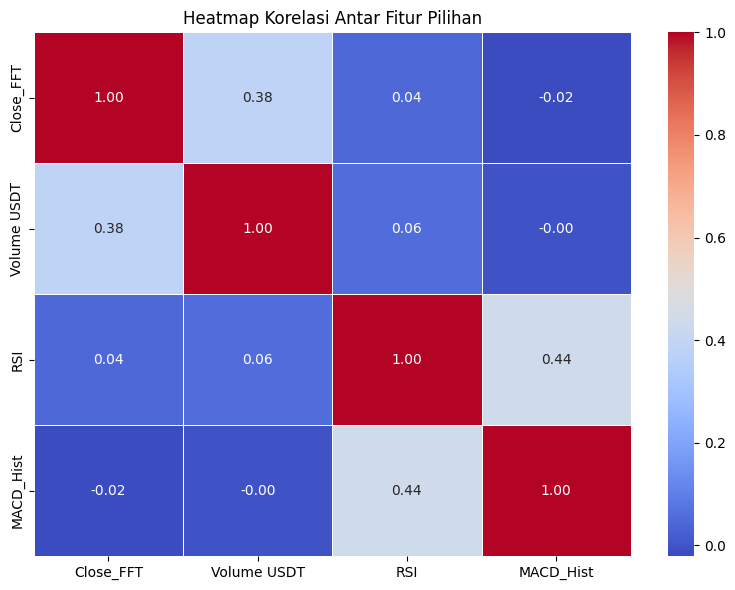

In [13]:
plt.figure(figsize=(8, 6))
# Menghitung korelasi antar fitur pilihan
correlation_matrix = df_filtered.corr()

# Membuat Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur Pilihan')
plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.api as sm

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Autocorrelation Function (ACF)
sm.graphics.tsa.plot_acf(df['Close_FFT'], lags=48, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')
axes[0].set_xlabel('Lags (Hours)')

# Plot Partial Autocorrelation Function (PACF)
sm.graphics.tsa.plot_pacf(df['Close_FFT'], lags=48, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF)')
axes[1].set_xlabel('Lags (Hours)')

plt.tight_layout()
plt.show()

In [14]:
def create_dataset(dataset, time_step=24):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        # Mengambil semua 4 fitur sebagai input
        X.append(dataset[i:(i + time_step), :])
        # Target prediksi: Close_FFT di jam berikutnya (kolom indeks 0)
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

# Menggunakan window 24 jam ke belakang
TIME_STEP = 24
X_train, y_train = create_dataset(train_scaled, TIME_STEP)
X_test, y_test = create_dataset(test_scaled, TIME_STEP)

print("Shape X_train:", X_train.shape) # Harus berupa (samples, 24, 4)
print("Shape y_train:", y_train.shape)

Shape X_train: (42495, 24, 4)
Shape y_train: (42495,)


In [16]:
# 1. Inisialisasi Model LSTM Dasar
model = Sequential([
    # input_shape=(time_steps, num_features) -> (24, 4)
    LSTM(units=50, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(units=1)
])

# 2. Compile Model
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# 3. Training Model Baseline
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,051 (43.17 KB)

 Trainable params: 11,051 (43.17 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.0013 - val_loss: 1.8021e-05
Epoch 2/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 1.6222e-05 - val_loss: 1.4231e-05
Epoch 3/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 1.2772e-05 - val_loss: 1.0389e-05
Epoch 4/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 1.0117e-05 - val_loss: 7.7601e-06
Epoch 5/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 9.5750e-06 - val_loss: 8.4180e-06
Epoch 6/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 7.3762e-06 - val_loss: 8.0997e-06
Epoch 7/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 6.0121e-06 - val_loss: 3.9129e-06
Epoch 8/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 4.9948e-06 - val_loss: 3.4993e-06
Epoch 9/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 4.9823e-06 - val_loss: 4.6301e-06
Epoch 10/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 3.5807e-06 - val_loss: 3.4257e-06
